## Instructions

Use NLP technologies to extract entities from medical notes data. To receive full credit, your project should yield Spacy, SciSpacy and Medspacy https://github.com/medspacy/medspacy extracted entities, word2vec, and tuned t-SNE plots for all three Python libraries. Compare and contrast the results you achieve. The incorporation of DisplaCy is encouraged but not required. See the rubric below for more information.

How to get medical notes: MIMIC NOTEEVENTS Table contains different kinds of medical reports. It is a file over >1 GB in size, so it might take 30 mins for you to load it in. We have provided python code that can help you extract a set of medical notes from NOTEEVENTS table. The example here shows how to extract discharge notes for patients diagnosed with ICD9 code 430 (Subarachnoid hemorrhage), which is also available with our lecture series resources. 

The NLP assignment features t-SNE, and you may run into a lot of confusion working with it for the first time. So please have a look at How to Use t-SNE Effectively. Tune your t-SNE plots. The addition of UMAP is encouraged but not required.

## Bonus 1 pt

To receive a bonus point for this assignment, you can introduce a new NLP tool such as cTakes, BERT, BlueBERT, ClinicalBERT, BioBERT or BioClinicalBERT. and apply it on MIMIC dataset.

> Please highlight any work intended for bonus credit.

## Submission

1. Your Python code file as a Jupyter notebook (.ipynb) -- with executed code blocks.
2. For each of spaCy, scispaCy and medspaCy, perform the entity extraction, word2vec and a tuned t-SNE. Show each of these results for each model in your slide presentation (not just a t-SNE). The use of displaCy is encouraged although not required. You are also encouraged to try UMAP in addition to (not instead of) t-SNE. Compare and contrast your results.
3. Slides (.pptx or .pdf), including your interpretation and comparison of your results.

# **Download Data**

In [1]:
"""
First download the data into a dataframe.
"""
import pandas as pd
from google.cloud import bigquery

PROJECT_ID = "project-eba4607b-9314-4a56-97d"
client = bigquery.Client(project=PROJECT_ID)

# Generalized query function
job_config = bigquery.QueryJobConfig(
    maximum_bytes_billed=10 * 1024**3  # 10 GB limit
)

def run_query(sql: str) -> pd.DataFrame:
    """Run a SQL query against BigQuery and return a pandas DataFrame."""
    return client.query(sql, job_config=job_config).to_dataframe()

# View all datasets I have access to
datasets = list(client.list_datasets(project="physionet-data"))
for d in datasets:
    print(d.dataset_id)

mimiciii_clinical
mimiciii_derived
mimiciii_notes
mimiciii_notes_derived
mimiciv_3_1_derived
mimiciv_3_1_hosp
mimiciv_3_1_icu


In [2]:

# View counts for specific diagnoses
# ^ Using BigQuery console to reference table and column names
# ^ Using mimic documentation for table relationship reference
# ^ https://mimic.mit.edu/docs/iii/tables/admissions.html
# ^ https://mimic.mit.edu/docs/iii/tables/diagnoses_icd.html

import os, pickle

P = "diagnoses_count_df.pkl"

if os.path.exists(P):
    diagnoses_count_df = pickle.load(open(P, "rb"))
else:
    diagnoses_count_df = run_query("""
        SELECT 
            count(d.icd9_code) as occurences,
            d.icd9_code as icd9_code,
            dx.long_title as diagnosis_name
        FROM `physionet-data.mimiciii_clinical.diagnoses_icd` d
        LEFT JOIN `physionet-data.mimiciii_clinical.d_icd_diagnoses` dx on d.icd9_code = dx.icd9_code
        GROUP BY d.icd9_code, dx.long_title
    """)

    pickle.dump(diagnoses_count_df, open(P, "wb"))

In [3]:
# Investigate what cohort I want to use, being mindful of data available
diagnoses_count_df = diagnoses_count_df.sort_values(by="occurences", ascending=False)
diagnoses_count_df.head(15)

,occurences,icd9_code,diagnosis_name
21,20703,4019,Unspecified essential hypertension
38,13111,4280,"Congestive heart failure, unspecified"
9,12891,42731,Atrial fibrillation
6,12429,41401,Coronary atherosclerosis of native coronary ar...
25,9119,5849,"Acute kidney failure, unspecified"
129,9058,25000,Diabetes mellitus without mention of complicat...
7,8690,2724,Other and unspecified hyperlipidemia
169,7497,51881,Acute respiratory failure
13,6555,5990,"Urinary tract infection, site not specified"
132,6326,53081,Esophageal reflux


In [4]:
""" 
Based on the results, I choose to investigate the cohort of patients who 
suffered from "Other and unspecified hyperlipidemia".

This condition is unknown to me, so I am curious of what entities 
and other information will be revealed.

I am choosing to limit to 100,000 roww since I do not have 
access to a powerful CPU or to a GPU. I ran the full 209,000 rows
last time and it crashed the kernel after 47 minutes.
"""

# ^ noteevents table documentation:
# ^ https://mimic.mit.edu/docs/iii/tables/noteevents.html

import os, pickle

P = "noteevents_df.pkl"

if os.path.exists(P):
    noteevents_df = pickle.load(open(P, "rb"))
else:
    noteevents_df = run_query("""
        SELECT
            n.text
        FROM `physionet-data.mimiciii_notes.noteevents` n
        LEFT JOIN `physionet-data.mimiciii_clinical.diagnoses_icd` d on n.hadm_id = d.hadm_id
        WHERE d.icd9_code = '2724'
        LIMIT 100000
    """)

    pickle.dump(noteevents_df, open(P, "wb"))

In [5]:
noteevents_df.info()
noteevents_df

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   text    100000 non-null  str  
dtypes: str(1)
memory usage: 258.2 MB


,text
0,TITLE:\n CVICU\n HPI:\n 60M s/p emergent...
1,TITLE:\n CVICU\n HPI:\n HD17\n [**3-28...
2,Admission Date: [**2189-2-6**] D...
3,Admission Date: [**2166-6-5**] D...
4,"Sinus rhythm, rate 64. Since the previous trac..."
...,...
99995,Technically difficult study\nSinus rhythm with...
99996,ECG interpreted by ordering physician.\n[**Nam...
99997,Admission Date: [**2118-5-26**] ...
99998,Admission Date: [**2109-5-13**] ...


# **spaCy NLP**

In [6]:
"""
Initializing and testing spaCY
"""

# ! pip install -U spacy
# ! python -m spacy download en_core_web_sm
import spacy
from spacy import displacy

# Load English tokenizer, tagger, parser and NER
nlp = spacy.load("en_core_web_sm")

# Process whole documents
text = ("When Sebastian Thrun started working on self-driving cars at "
        "Google in 2007, few people outside of the company took him "
        "seriously. “I can tell you very senior CEOs of major American "
        "car companies would shake my hand and turn away because I wasn’t "
        "worth talking to,” said Thrun, in an interview with Recode earlier "
        "this week.")
doc = nlp(text)

# Analyze syntax
print("Noun phrases:", [chunk.text for chunk in doc.noun_chunks])
print("Verbs:", [token.lemma_ for token in doc if token.pos_ == "VERB"])

# Find named entities, phrases and concepts
for entity in doc.ents:
    print(entity.text, entity.label_)

sentence_spans = list(doc.sents)
displacy.render(sentence_spans, style="dep", minify=True)
displacy.render(sentence_spans, style="ent")
displacy.render(sentence_spans, style="span")

Noun phrases: ['Sebastian Thrun', 'self-driving cars', 'Google', 'few people', 'the company', 'him', 'I', 'you', 'very senior CEOs', 'major American car companies', 'my hand', 'I', 'Thrun', 'an interview', 'Recode']
Verbs: ['start', 'work', 'drive', 'take', 'tell', 'shake', 'turn', 'talk', 'say']
Sebastian Thrun PERSON
Google ORG
2007 DATE
American NORP
Thrun PERSON
Recode ORG
earlier this week DATE


c:\Users\laesc\anaconda3\envs\rl\Lib\site-packages\spacy\displacy\__init__.py:244: UserWarning: [W117] No spans to visualize found in Doc object with spans_key: 'sc'. If this is surprising to you, make sure the Doc was processed using a model that supports span categorization, and check the `doc.spans[spans_key]` property manually if necessary.

Available keys: []
  warnings.warn(Warnings.W117.format(spans_key=spans_key, keys=keys))


In [ ]:
"""
Extract entities across all notes. Using pickle due to kernel crashing issues.

I did not need to do this.
"""

import os, pickle
from tqdm.auto import tqdm

P = "spacy_entities.pkl"
if os.path.exists(P):
    spacy_entities = pickle.load(open(P, "rb"))
else:
    nlp = spacy.load("en_core_web_sm", exclude=["parser", "lemmatizer", "attribute_ruler", "tagger"]) # Drop unnecessary components to save processing time

    text = noteevents_df['text'].dropna()
    spacy_entities = {}

    for doc in tqdm(nlp.pipe(text, batch_size=100, n_process=4), total=len(text), desc="Extracting entities"):
        for entity in doc.ents:
            if entity.text not in spacy_entities:
                spacy_entities[entity.text] = [entity.label_]

pickle.dump(spacy_entities, open(P, "wb"))

In [8]:
"""
Build the entity token corpus
"""

import os, pickle
from tqdm.auto import tqdm

P = "corpus_entities.pkl"

if os.path.exists(P):
    with open(P, "rb") as f:
        corpus = pickle.load(f)
else:
    nlp = spacy.load("en_core_web_sm", exclude=["parser", "lemmatizer", "attribute_ruler", "tagger"])

    text = noteevents_df['text'].dropna().sample(frac=0.5, random_state=42)
    corpus = []

    for doc in tqdm(nlp.pipe(text, batch_size=100, n_process=4), total=len(text), desc="Extracting entities"):
        corpus.append([ent.text for ent in doc.ents])

    with open(P, "wb") as f:
        pickle.dump(corpus, f)

Extracting entities:   0%|          | 0/50000 [00:00<?, ?it/s]

In [17]:
"""
Train word2vec on the corpus
"""

from gensim.models import Word2Vec

# Removing these entities because it filled the plot with numbers
skip = {"CARDINAL", "PERCENT", "QUANTITY", "TIME", "DATE", "ORDINAL", "MONEY"}

corpus_filtered = [
    [e for e in note if spacy_entities.get(e, [""])[0] not in skip]
    for note in corpus
]

model = Word2Vec(corpus_filtered, min_count=5)

In [ ]:
"""
Define t-SNE plot
"""

import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def tsne_plot(model, words, preTrained=False, entity_labels=None):
    "Creates a TSNE model and plots it, colored by entity type if entity_labels is given"
    labels = []
    tokens = []

    for word in words:
        if preTrained:
            tokens.append(model[word])
        else:
            tokens.append(model.wv[word])
        labels.append(word)

    tokens = np.array(tokens)
    tsne_model = TSNE(perplexity=30, early_exaggeration=12, n_components=2, init='pca', max_iter=1000, random_state=23)
    new_values = tsne_model.fit_transform(tokens)

    x = new_values[:, 0]
    y = new_values[:, 1]

    # Map each word to its entity type, e.g. "PERSON", "ORG", "GPE"
    if entity_labels is not None:
        types = [entity_labels.get(w, ["UNKNOWN"])[0] for w in labels]
    else:
        types = ["ALL"] * len(labels)

    unique_types = sorted(set(types))
    cmap = plt.get_cmap("tab20")
    colors = {t: cmap(i % 20) for i, t in enumerate(unique_types)}

    plt.figure(figsize=(16, 16))
    for i in range(len(x)):
        c = colors[types[i]]
        plt.scatter(x[i], y[i], color=c)
        plt.annotate(labels[i],
                     xy=(x[i], y[i]),
                     xytext=(5, 2),
                     textcoords='offset points',
                     ha='right',
                     va='bottom',
                     color=c)

    # Legend with one entry per entity type
    handles = [Line2D([0], [0], marker='o', linestyle='', color=colors[t], label=t)
               for t in unique_types]
    plt.legend(handles=handles, title="Entity type", loc="upper left")
    plt.show()


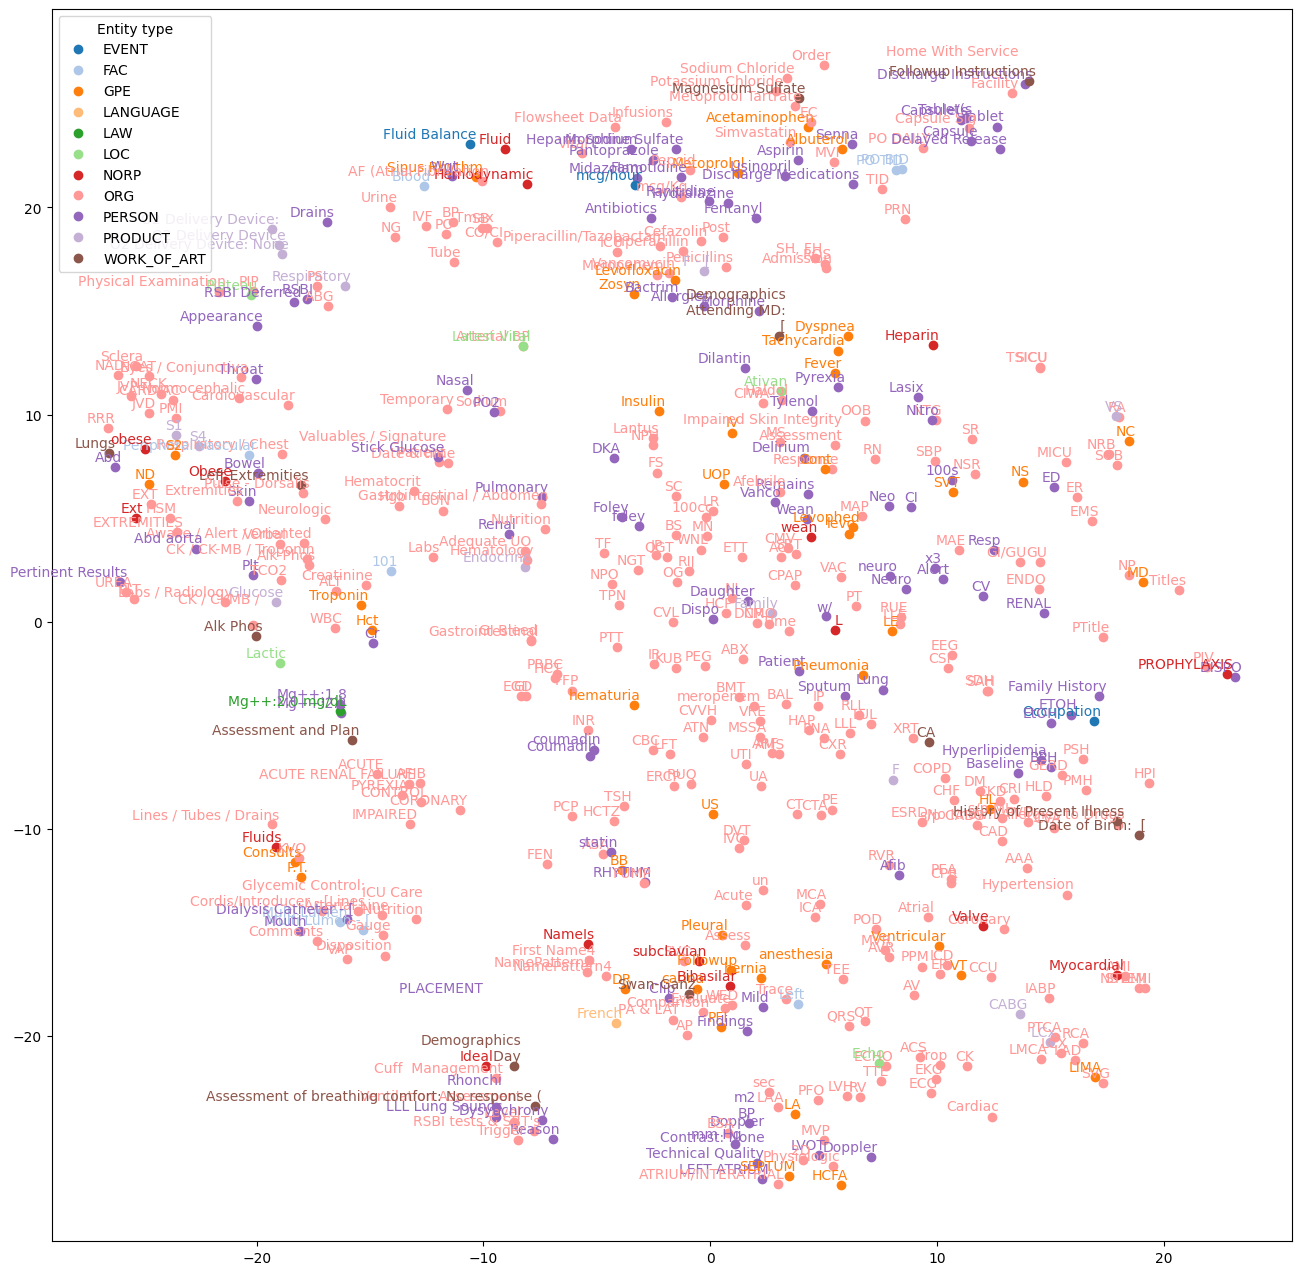

In [ ]:
"""
Print plot for the corpus
"""
vocabs = list(model.wv.key_to_index.keys())[:500]
new_v = np.array(vocabs)
tsne_plot(model, new_v, entity_labels=spacy_entities)

"""
We can see that while word2vec meaningfully clustered entities,
the labels from the general spaCy NER model are not meaningful
or correct whatsoever.
"""

# **scispaCy**

In [ ]:
# Update requirements file
import sys
!{sys.executable} -m pipreqs.pipreqs . --force --scan-notebooks

Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
Please, verify manually the final list of requirements.txt to avoid possible dependency confusions.
